In [1]:
import os
os.getcwd()

'c:\\Users\\giovanni.sgaravatti\\Bruegel Gitlab\\2021-11-european-natural-gas-imports'

In [2]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports'

In [3]:
os.chdir(Share_point)

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [5]:
# Converter for metric tonnes to M3m 
converter = -0.001397

### In Million tonnes

In [11]:
d1 = pd.read_excel('raw_data/LNG/Europe LNG 2017_2018.xlsx',index_col=1)
d2 = pd.read_excel('raw_data/LNG/Europe LNG 2019_2020.xlsx',index_col=1)
d3 = pd.read_excel('raw_data/LNG/Europe LNG 2021_2022.xlsx',index_col=1)
d4 = pd.read_excel('raw_data/LNG/Europe LNG 2023.xlsx',index_col=1)

In [12]:
# Merge 2017 to 2020
df_20 = pd.merge(d1,d2,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [13]:
# Merge 2017 to 2022
df_22 = pd.merge(df_20,d3,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [14]:
# Merge 2022 to 2023
df = pd.merge(df_22,d4,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [15]:
not_EU = ['United Kingdom','Turkey']
df_EU27 = df.loc[~df['Port_Country'].isin((not_EU))] 

### Single-out Spain and Portugal

In [16]:
df_tot = df_EU27.reset_index()

In [17]:
iberia = df_tot[df_tot['Port_Country'].isin(['Spain','Portugal'])]

In [13]:
cols = iberia.iloc[:,:2]

In [14]:
# convert to M3m
values = iberia.iloc[:,2:]*converter

In [21]:
iberia = pd.concat([cols,values], axis=1)

In [22]:
iberia.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\Iberian LNG by source.xlsx')

## Back to recurrent code

In [18]:
## Here we get 
dff = df_EU27.groupby(['Origin_Berthcountry']).sum(numeric_only=True)

In [19]:
dff_T = dff.T #drop(['nan_x','nan_y'])

In [20]:
dff_T.index = pd.to_datetime(dff_T.index)
dff_T = dff_T.sort_index()

### in M3m

In [21]:
dff_M3m = dff_T * converter

In [22]:
# Remove European re-exports
del dff_M3m['Belgium']
del dff_M3m['France']
del dff_M3m['Lithuania']
del dff_M3m['Netherlands']
del dff_M3m['Spain']

In [23]:
dff_EU = dff_M3m

In [24]:
dff_M3m.columns

Index(['Algeria', 'Angola', 'Argentina', 'Australia', 'Brazil', 'Cameroon',
       'China', 'Dominican Republic', 'Egypt', 'Equatorial Guinea',
       'Indonesia', 'Jamaica', 'Malaysia', 'Mozambique', 'Nigeria', 'Norway',
       'Oman', 'Peru', 'Qatar', 'Russia', 'Singapore', 'South Korea',
       'Trinidad & Tobago', 'United Arab Emirates', 'United Kingdom',
       'United States of America'],
      dtype='object', name='Origin_Berthcountry')

In [25]:
dff_M3m.tail()

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Brazil,Cameroon,China,Dominican Republic,Egypt,Equatorial Guinea,...,Oman,Peru,Qatar,Russia,Singapore,South Korea,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America
2023-03-31,641.264491,185.616456,-0.0,-0.0,-0.000000,185.038098,-0.0,-0.0,137.843457,301.589180,...,85.535376,-0.000000,1189.606968,1487.378356,-0.0,-0.0,92.458699,-0.0,-0.0,5137.298253
2023-04-30,1004.806499,368.506458,-0.0,-0.0,-0.000000,199.019903,-0.0,-0.0,110.032610,-0.000000,...,258.549286,-0.000000,1732.346916,1593.271305,-0.0,-0.0,217.391571,-0.0,-0.0,6279.173713
2023-05-31,683.663162,278.850280,-0.0,-0.0,-0.000000,99.563072,-0.0,-0.0,296.091007,100.719788,...,99.544842,98.669761,1656.981840,1757.839931,-0.0,-0.0,142.391111,-0.0,-0.0,5554.147896
2023-06-30,975.285724,185.113536,-0.0,-0.0,-0.000000,-0.000000,-0.0,-0.0,165.998176,-0.000000,...,97.320049,254.906259,1541.691202,1361.039194,-0.0,-0.0,443.537092,-0.0,-0.0,5408.005630
2023-07-31,900.196625,370.782799,-0.0,-0.0,89.025012,-0.000000,-0.0,-0.0,-0.000000,90.492282,...,-0.000000,-0.000000,1700.637810,1587.913321,-0.0,-0.0,471.989791,-0.0,-0.0,4916.276858


In [26]:
include = ['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt']
exclude = list(set(dff_M3m.columns)-set(include))

In [27]:
## Define an "Other" category
dff_M3m['Other']= dff_M3m[exclude].sum(axis=1)

In [28]:
# dff_M3m['Argentina'].loc['2020':]+dff_M3m['Brazil'].loc['2020':]+dff_M3m['Peru'].loc['2020':]

In [29]:
os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')

In [30]:
dff_M3m['month'] = dff_M3m.index.strftime("%m")

In [31]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

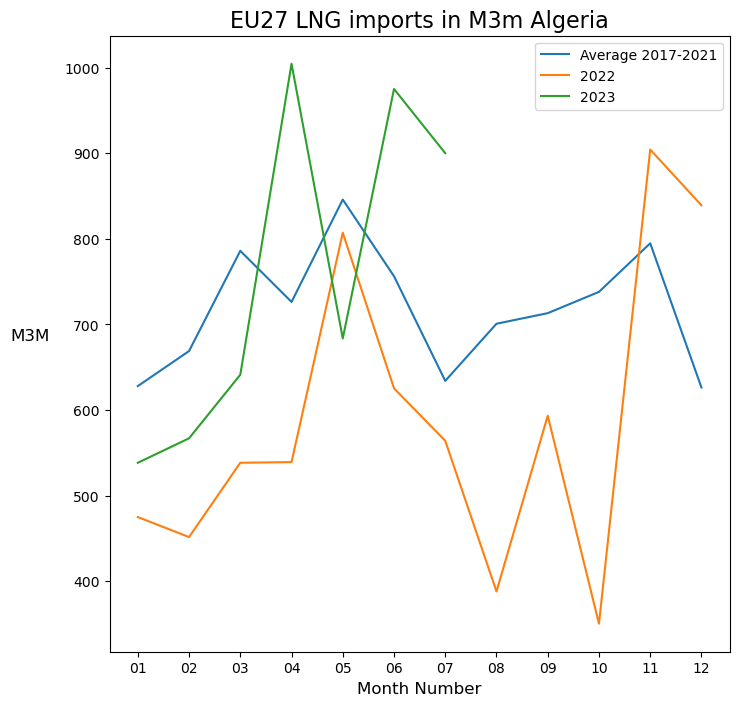

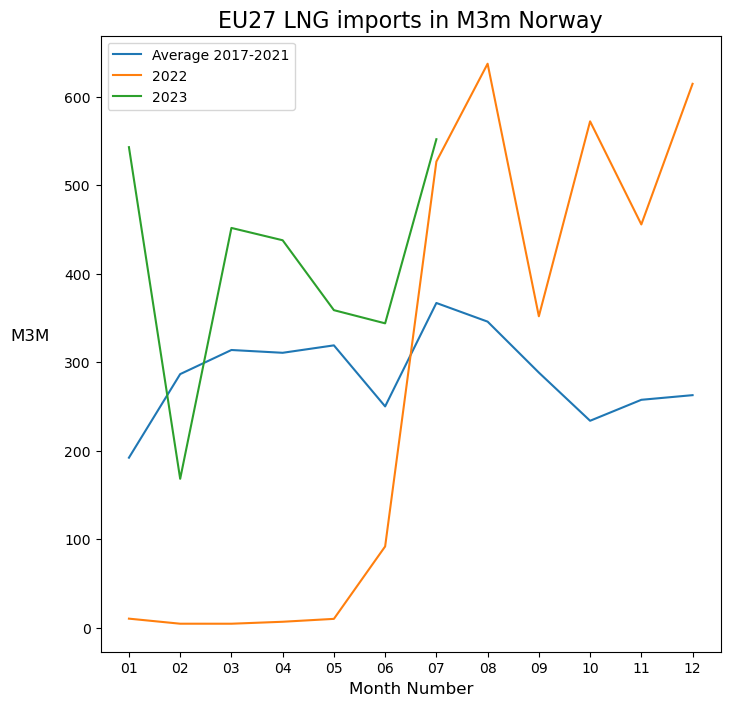

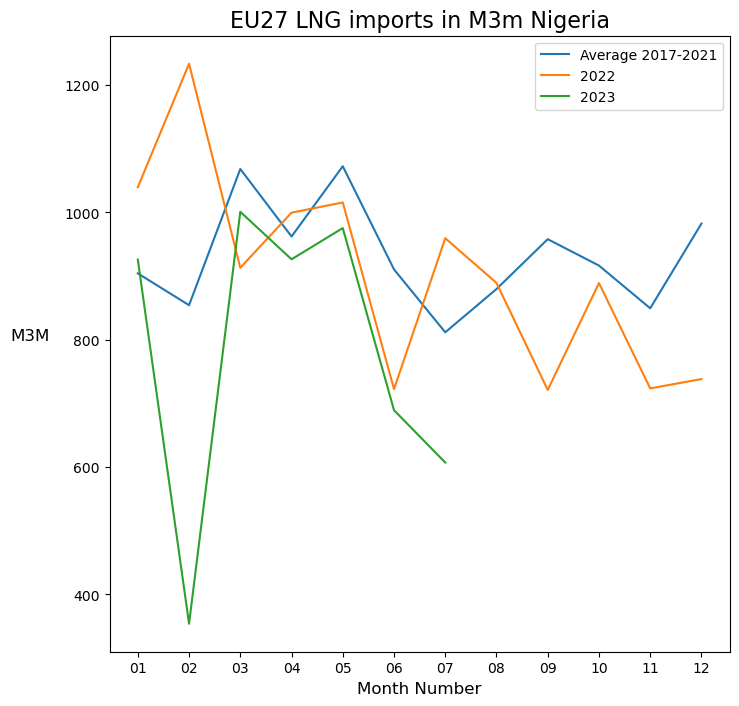

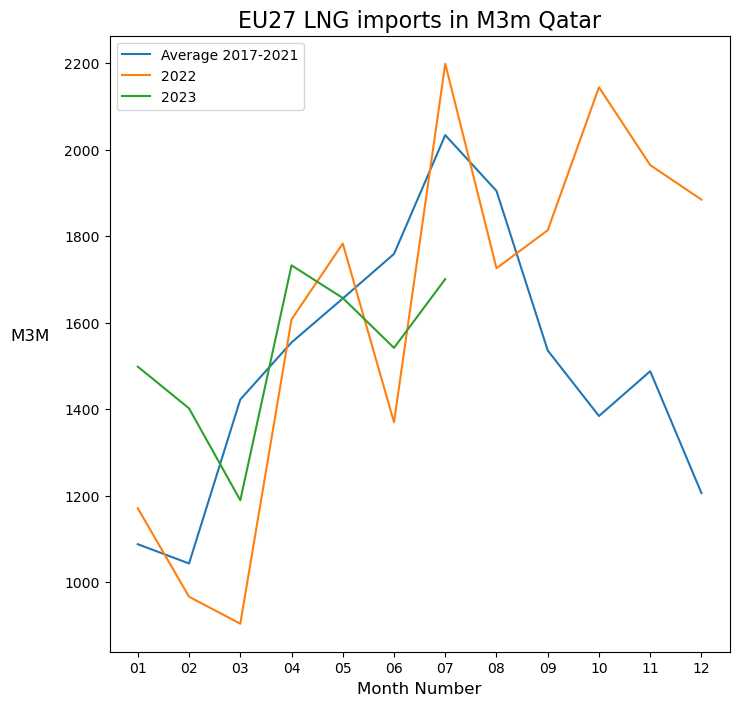

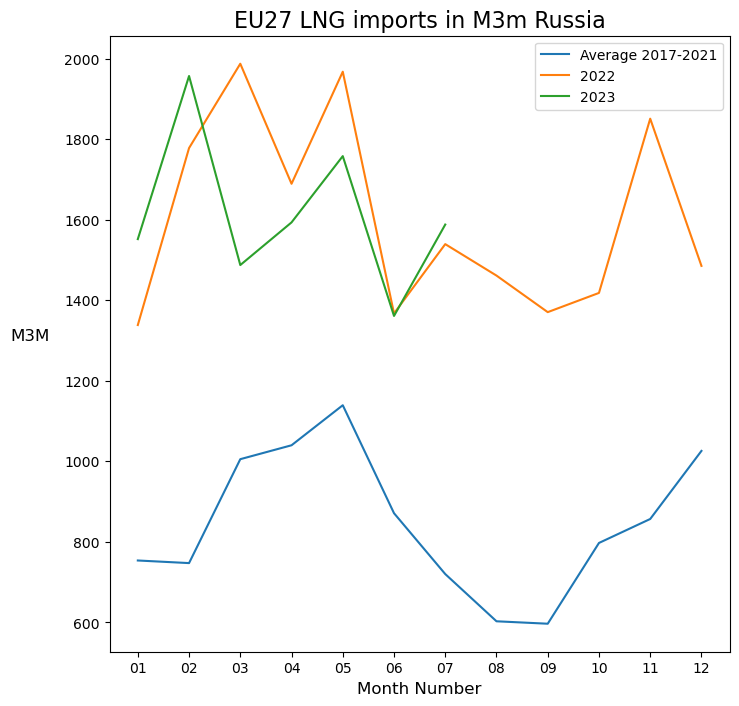

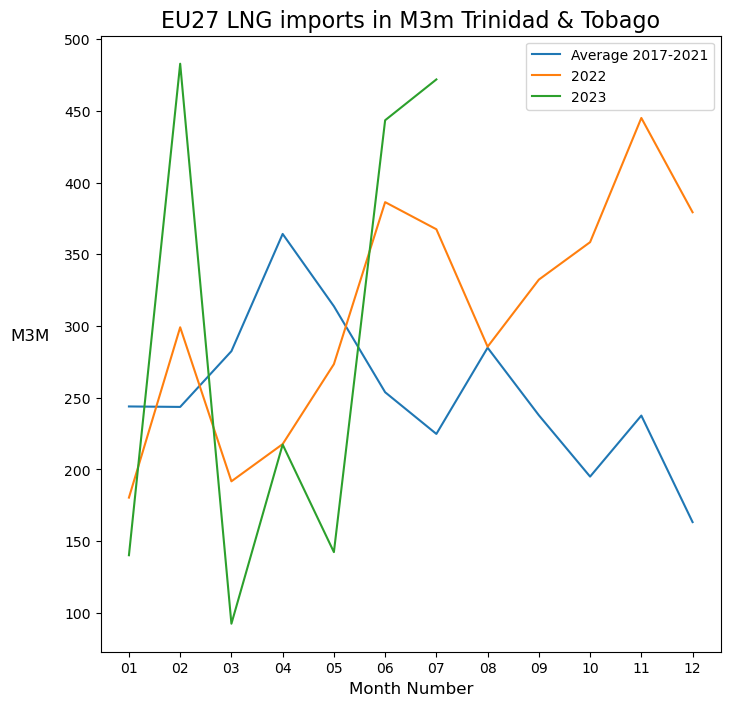

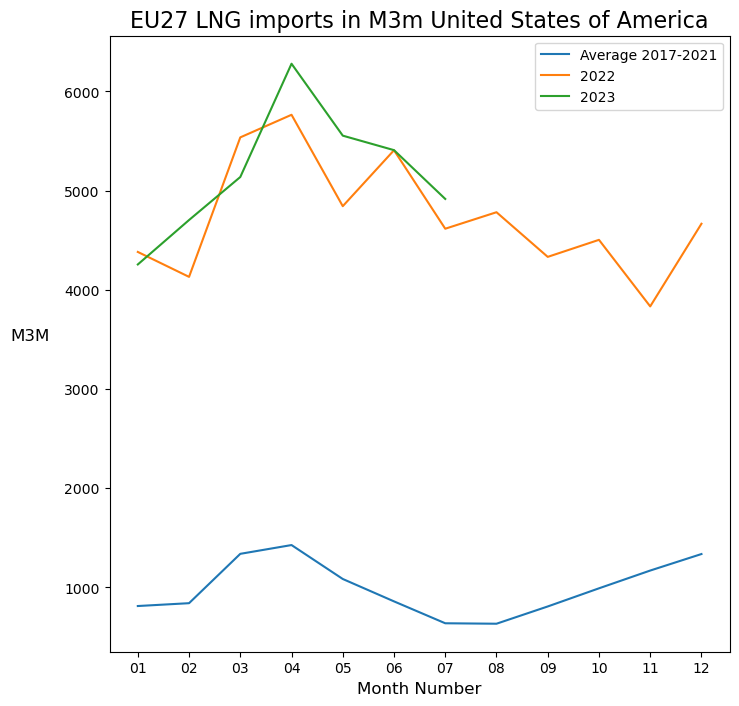

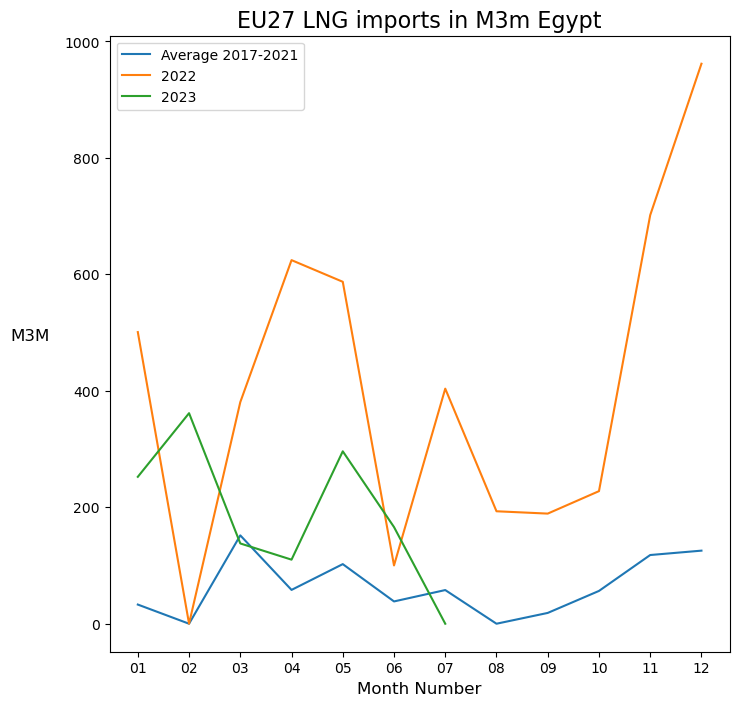

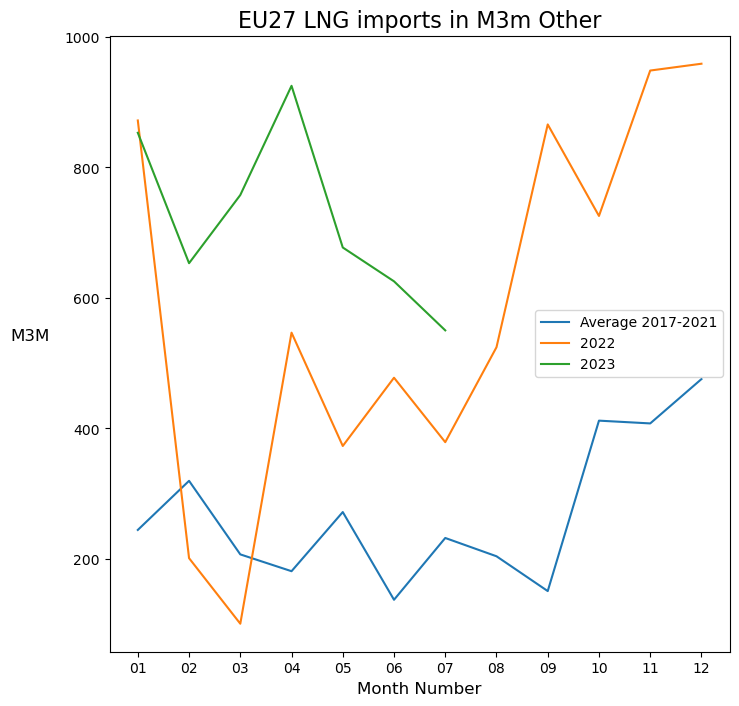

In [38]:
### From country of origin

data = pd.DataFrame()
for country in ['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt','Other']:

    ctemp = dff_M3m[country][:'2023-07-31']
    ctemp=ctemp.to_frame()
    ctemp['month'] = ctemp.index.strftime("%m")
    
#     minvalues = ctemp.loc['2017':'2020'].groupby('month').min()
#     maxvalues = ctemp.loc['2017':'2020'].groupby('month').max()
    avgvalues = ctemp.loc['2017':'2021'].groupby('month').mean()   
#     values2021 = ctemp.loc['2021'].groupby('month').mean()   
    values2022 = ctemp.loc['2022'].groupby('month').max()
    values2023 = ctemp.loc['2023'].groupby('month').max()
    
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(avgvalues,label='Average 2017-2021')
#     ax.plot(values2021,label='2021')
    ax.plot(values2022,label='2022')
    ax.plot(values2023,label='2023')

    plt.title('EU27 LNG imports in M3m {}'.format(country),fontsize='16')
    plt.ylabel('M3M',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Month Number',fontsize=12,rotation=0)
    plt.legend()
    plt.show()
    fig.savefig('pictures/{}.png'.format(country),dpi=300,bbox_inches="tight")

#     data['{}_min'.format(country)] = minvalues
#     data['{}_max'.format(country)] = maxvalues
    data['{}_avg'.format(country)] = avgvalues
#     data['{}_2021'.format(country)] = values2021 
    data['{}_2022'.format(country)] = values2022
    data['{}_2023'.format(country)] = values2023

In [39]:
today = date.today()    
data = data.round(1)
data.to_csv('LNG_imports_avg_{}.csv'.format(today))

#### Get only 2019 onwards values

In [40]:
df_late =dff_M3m.loc['2019':]

In [41]:
df_late=df_late.rename(columns={'United States of America':'United States'})

In [42]:
df_late=df_late.drop('month',axis=1)
df_late = df_late[['Qatar','Algeria','Nigeria','Russia','Norway','United States','Trinidad & Tobago','Egypt','Other']]

In [43]:
df_late.to_excel(r'Bloomberg/granular LNG imports.xlsx')

#### Aggregate to avoid problems with Bloomberg

In [44]:
dff_EU = dff_EU.loc['2019':]

In [45]:
dff_EU.columns

Index(['Algeria', 'Angola', 'Argentina', 'Australia', 'Brazil', 'Cameroon',
       'China', 'Dominican Republic', 'Egypt', 'Equatorial Guinea',
       'Indonesia', 'Jamaica', 'Malaysia', 'Mozambique', 'Nigeria', 'Norway',
       'Oman', 'Peru', 'Qatar', 'Russia', 'Singapore', 'South Korea',
       'Trinidad & Tobago', 'United Arab Emirates', 'United Kingdom',
       'United States of America', 'Other', 'month'],
      dtype='object', name='Origin_Berthcountry')

In [46]:
exclude_2 = ['Argentina','Australia','Brazil','China','Indonesia','Jamaica','Malaysia','Peru','United Kingdom','Singapore','South Korea']

In [47]:
set(dff_EU.columns)-set(exclude_2)

{'Algeria',
 'Angola',
 'Cameroon',
 'Dominican Republic',
 'Egypt',
 'Equatorial Guinea',
 'Mozambique',
 'Nigeria',
 'Norway',
 'Oman',
 'Other',
 'Qatar',
 'Russia',
 'Trinidad & Tobago',
 'United Arab Emirates',
 'United States of America',
 'month'}

In [48]:
dff_EU['Other']=dff_EU[exclude_2].sum(axis=1)

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_2584\1128151473.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_EU['Other']=dff_EU[exclude_2].sum(axis=1)


In [49]:
dff_EU['America'] = dff_EU['United States of America']+dff_EU['Trinidad & Tobago']+dff_EU['Dominican Republic']
dff_EU['Africa'] = dff_EU['Algeria']+dff_EU['Angola']+dff_EU['Nigeria']+dff_EU['Egypt']+dff_EU['Cameroon']+dff_EU['Equatorial Guinea']+dff_EU['Mozambique']
dff_EU['Middle East'] = dff_EU['Qatar']+dff_EU['Oman']+dff_EU['United Arab Emirates']
dff_EU['Other']=dff_EU['Other']+dff_EU['Norway']

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_2584\614410288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_EU['America'] = dff_EU['United States of America']+dff_EU['Trinidad & Tobago']+dff_EU['Dominican Republic']
C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_2584\614410288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_EU['Africa'] = dff_EU['Algeria']+dff_EU['Angola']+dff_EU['Nigeria']+dff_EU['Egypt']+dff_EU['Cameroon']+dff_EU['Equatorial Guinea']+dff_EU['Mozambi

In [50]:
dff_EU.head()

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Brazil,Cameroon,China,Dominican Republic,Egypt,Equatorial Guinea,...,South Korea,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Other,month,America,Africa,Middle East
2019-01-31,625.450800,-0.000000,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,-0.000000,...,-0.0,443.950115,-0.0,-0.0,838.232480,440.322176,01,1282.182596,1747.244664,1365.784245
2019-02-28,669.675070,286.418598,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,-0.000000,...,-0.0,437.597607,-0.0,-0.0,596.845968,613.156921,02,1034.443575,1789.786667,1112.046017
2019-03-31,758.590698,93.134497,-0.0,-0.0,-0.0,86.652487,-0.0,-0.0,205.818124,-0.000000,...,-0.0,562.632320,-0.0,-0.0,1342.418581,524.331190,03,1905.050902,2291.817756,1789.489315
2019-04-30,1069.100421,92.879266,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,205.835726,-0.000000,...,-0.0,708.035293,-0.0,-0.0,1290.129989,433.777301,04,1998.165282,2512.502824,1448.473722
2019-05-31,902.378669,93.134497,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0,190.904031,165.732257,...,-0.0,437.471249,-0.0,-0.0,845.326796,427.813927,05,1282.798044,2410.520706,1718.531704


In [51]:
df_plot = dff_EU[['America','Africa','Middle East','Russia','Other']]

In [52]:
df_plot.head()

Origin_Berthcountry,America,Africa,Middle East,Russia,Other
2019-01-31,1282.182596,1747.244664,1365.784245,1159.658711,440.322176
2019-02-28,1034.443575,1789.786667,1112.046017,1152.223038,613.156921
2019-03-31,1905.050902,2291.817756,1789.489315,1709.091895,524.331190
2019-04-30,1998.165282,2512.502824,1448.473722,1890.841526,433.777301
2019-05-31,1282.798044,2410.520706,1718.531704,1969.238581,427.813927


In [53]:
df_plot['dates'] = df_plot.index.strftime('%m/%Y')

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_2584\4259429885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['dates'] = df_plot.index.strftime('%m/%Y')


In [54]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [55]:
today

datetime.date(2023, 8, 16)

In [56]:
df_plot.to_excel(r'Bloomberg\LNG plot data {}.xlsx'.format(today))

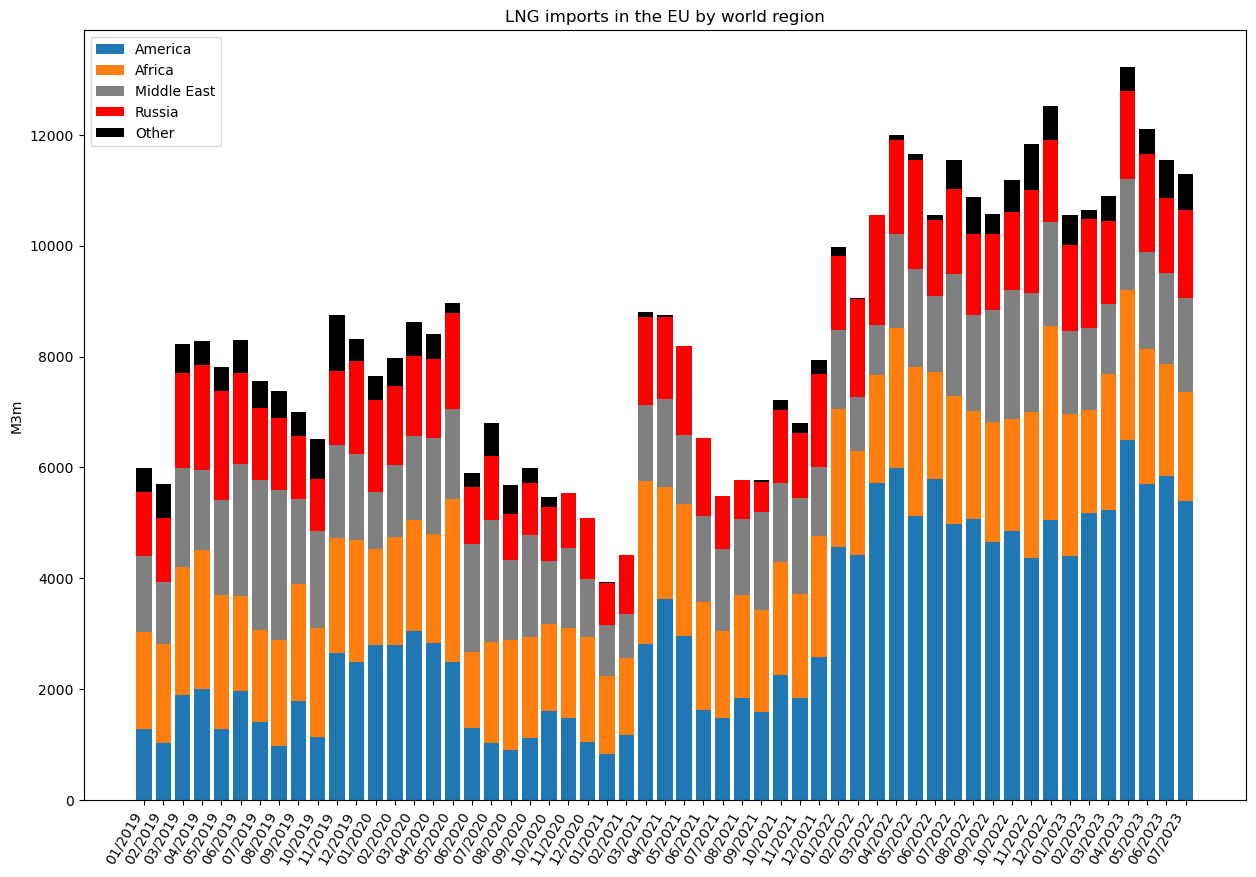

In [57]:
x = df_plot['dates']
width = 0.80       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, df_plot['America'], width, label='America')
ax.bar(x, df_plot['Africa'], width, bottom=df_plot['America'],
       label='Africa')
ax.bar(x, df_plot['Middle East'], width, bottom=df_plot['America']+df_plot['Africa'],
       label='Middle East',color='gray')
ax.bar(x, df_plot['Russia'], width, bottom=df_plot['America']+df_plot['Africa']+df_plot['Middle East'],
       label='Russia',color='red')
ax.bar(x, df_plot['Other'], width, bottom=df_plot['America']+df_plot['Africa']+df_plot['Middle East']+df_plot['Russia'],
       label='Other',color='black')

fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by world region')
ax.legend()

plt.show()

### In bcm

In [132]:
df_late.columns

Index(['Qatar', 'Algeria', 'Nigeria', 'Russia', 'Norway', 'United States',
       'Trinidad & Tobago', 'Egypt', 'Other'],
      dtype='object', name='Origin_Berthcountry')

In [128]:
df_bcm = df_late/1000

In [129]:
df_bcm = df_bcm['2021-09':]

In [ ]:
df_bcm.plot(figsize=(15, 9),kind='area',ylabel='bcm', title='LNG imports in the EU by supplier')

In [130]:
df_twh = df_bcm*10.3 

In [133]:
df_twh = df_twh[['United States','Russia', 'Qatar',  'Norway', 'Algeria', 'Nigeria', 'Trinidad & Tobago', 'Egypt', 'Other']]

In [141]:
colors = {'United States':'#0080C7','Russia':'#E67425', 'Qatar':'#FFC000',  'Norway':'black', 'Algeria':'orange', 'Nigeria':'#2BB0CB', 'Trinidad & Tobago':'#0080C7', 'Egypt':'blue', 'Other':'#58A944'}

<Axes: title={'center': 'LNG imports in the EU by supplier'}, ylabel='bcm'>

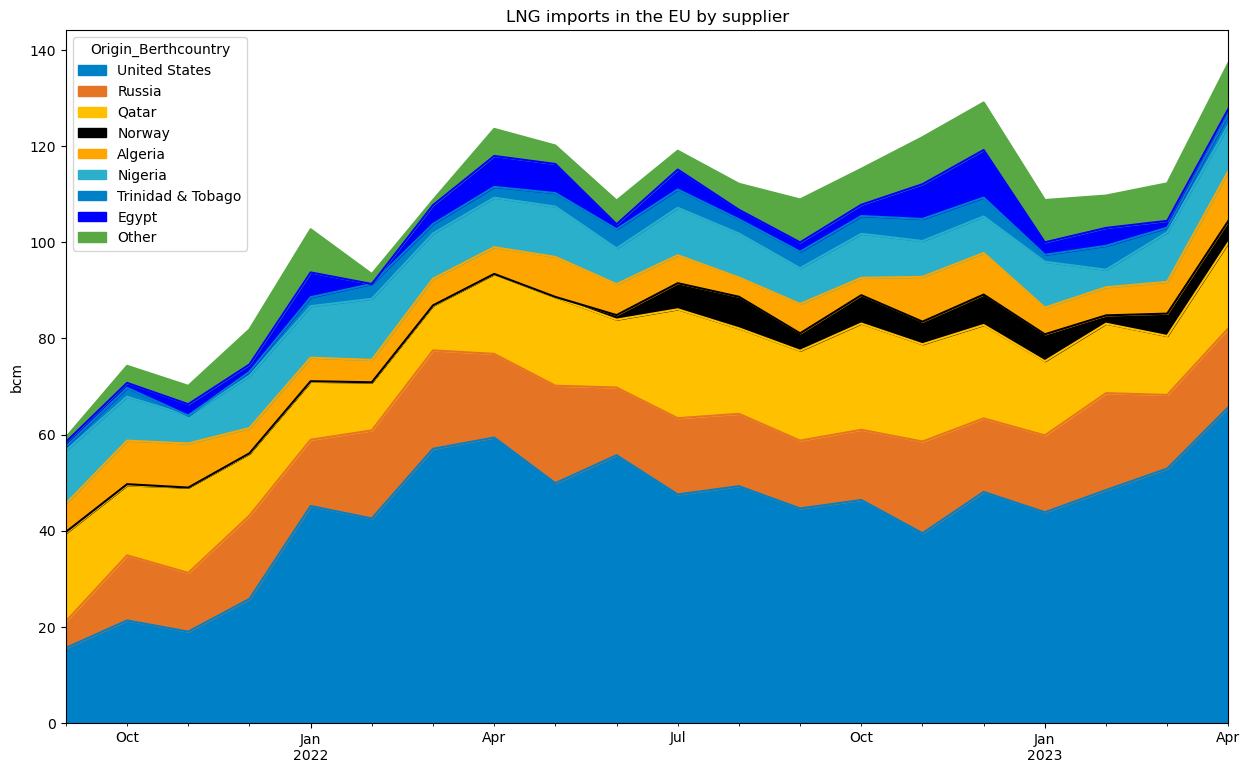

In [142]:
df_twh.plot(figsize=(15, 9),kind='area',ylabel='bcm', title='LNG imports in the EU by supplier',color=colors)

### Checks against the Quarterly report of the Commission

In [49]:
df_bcm['M_Y'] = df_bcm.index.strftime('%m_%Y')

<Axes: title={'center': 'LNG imports in the EU by supplier'}, xlabel='month', ylabel='bcm'>

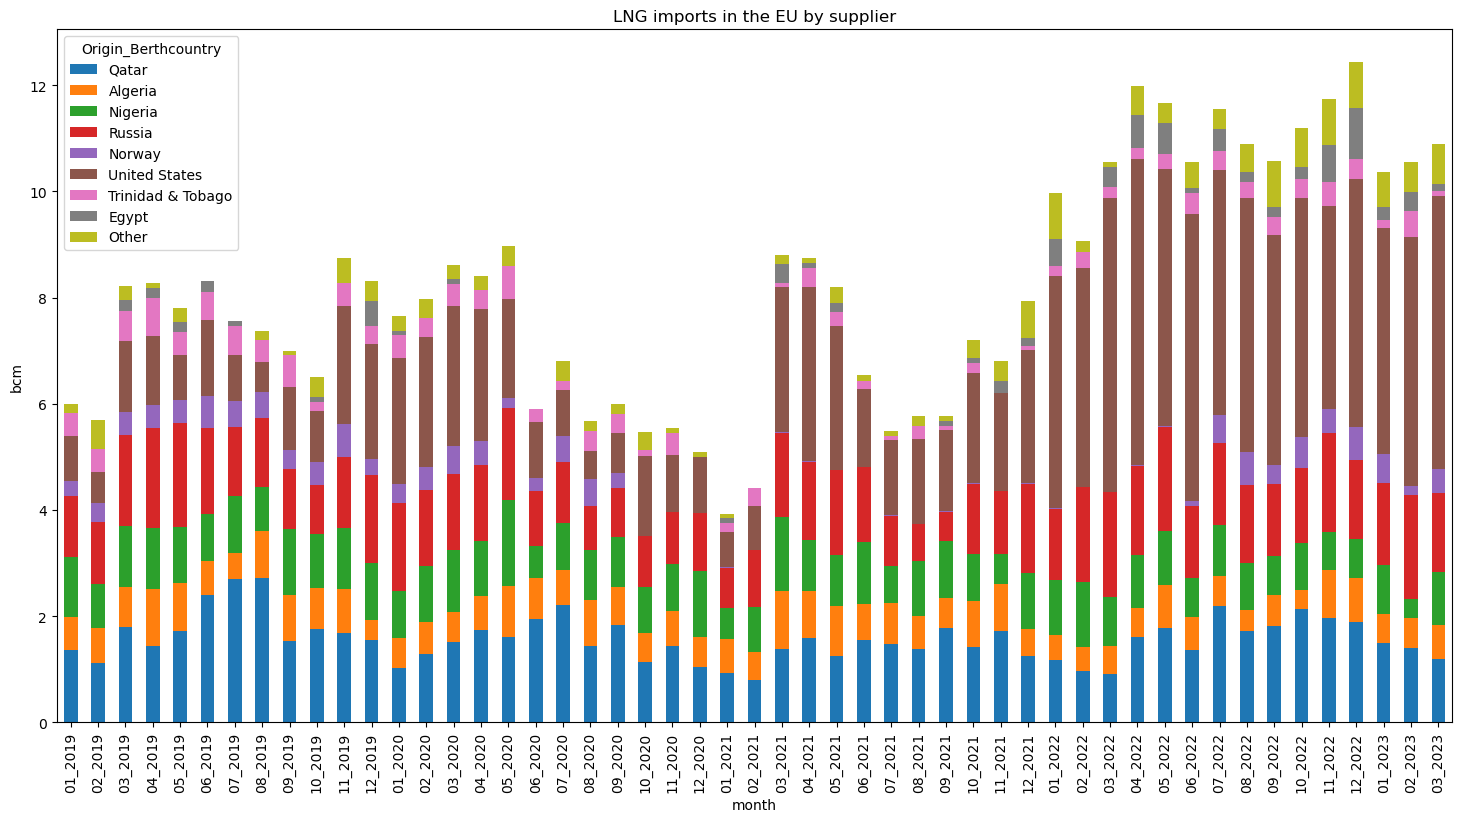

In [50]:
df_bcm.plot(x='M_Y', kind='bar', stacked=True,
        title='LNG imports in the EU by supplier',figsize=(18, 9),
           ylabel='bcm', xlabel='month')

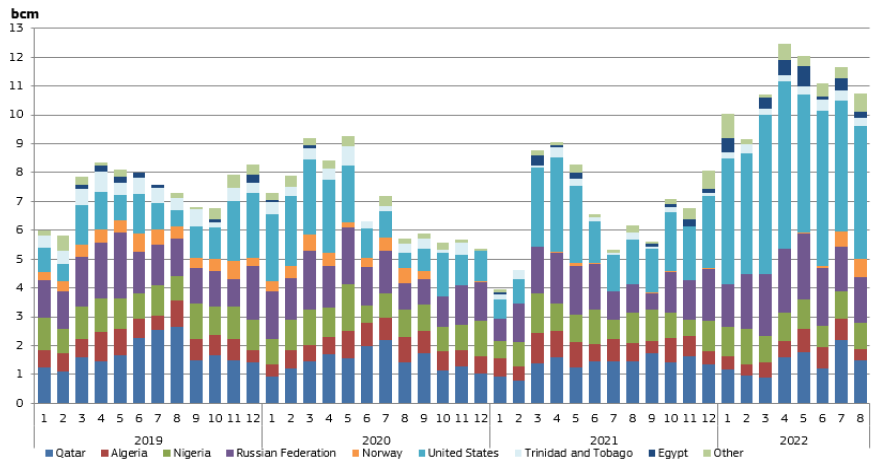

In [51]:
from IPython.display import Image
Image("Commission Qreport.png")

In the second quarter of 2022, the United States proved to be the biggest LNG supplier of the EU, by a large margin to its competitors, ensuring 16 bcm of the EU LNG imports within a single quarter (for comparison: EU LNG imports from the US amounted to 22 bcm in 2021 as whole), representing around 45% of the total imports. Year-on-year, LNG imports from the US were up by 117%, and the share of the US in total EU LNG imports rose by 14 percentage points. In 2022 so far, the EU imported around 39 bcm LNG from the US, implying that the objective of the March 2022 EU-US joint statement on energy security12, which foresaw and increase of 15 bcm compared to 2021, has already been fulfilled.

In [263]:
df_bcm['United States'].loc['2022-04':'2022-06'].sum()

16.015097637

In [264]:
df_bcm['United States'].loc['2021'].sum()

22.53646693485

In [268]:
df_bcm['United States'].loc['2022-01':'2022-08'].sum()

39.365310505950006

In spite of ongoing geopolitical tensions, Russia remained the second biggest LNG supplier of the EU, representing 18% (6.5 bcm, up by 28% year-on-year). Qatar was the third most important EU LNG source (with an import share of 13% and imports amounting to 4.6 bcm, +7%), followed by Nigeria on the fourth place (with an import share of only 8% - 2.7 bcm, but falling by 11% year-on-year). LNG imports from Algeria amounted to 2.1 bcm, falling by 12% year-on-year and representing only 6% of the total imports. Within other sources, LNG imports from Egypt rose almost five-fold year-on-year, reaching 1.3 bcm (4% of the total EU imports), while those from Trinidad and Tobago amounted to 0.9 bcm and ensured around 3% of the total EU LNG imports – See Figure 16

In [273]:
df_bcm['Russia'].loc['2022-04':'2022-06'].sum()

5.0237910954

In [275]:
df_bcm['Qatar'].loc['2022-04':'2022-06'].sum()

4.7600812215

In [276]:
df_bcm['Nigeria'].loc['2022-04':'2022-06'].sum()

2.7380190667499997

In [277]:
df_bcm['Algeria'].loc['2022-04':'2022-06'].sum()

1.9717380936

In [280]:
dff_M3m['Egypt'].loc['2022-04':'2022-06'].sum() # in M3m

1311.6933126000001

In [279]:
df_bcm['Trinidad & Tobago'].loc['2022-04':'2022-06'].sum()

0.8776060870500001

In Q2 2022, Norway still had a very low share (around 0.3%) in total EU LNG imports, however, in June the Hammerfest LNG liquefaction terminal restarted its operation, being under repair and maintenance works since the fire incident at the end of September 2020 (See more in Chapter 1.4) and is expected to measurably contribute to the EU LNG supply as of from the second half of 2022.

In [323]:
N=df_bcm['Norway'].loc['2022-04':'2022-06'].sum()
T=df_bcm[['Qatar','Algeria','Nigeria','Russia','Norway','United States','Trinidad & Tobago','Egypt','Other']].loc['2022-04':'2022-06'].sum()

In [326]:
TT= T.sum()

In [328]:
N/TT*100

0.3171755705759158